# Simple Encoder-decoder Architecture without Attention mechanism

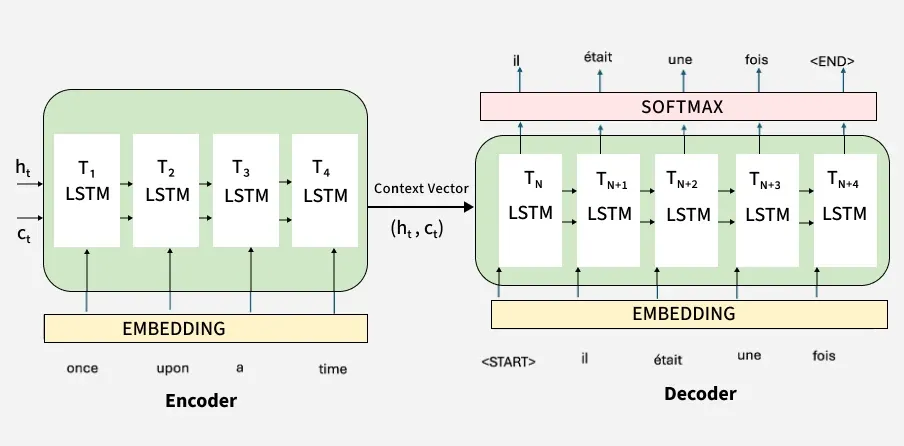

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

## Build Encoder 

In [879]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, emb_size, hidden_size, batch_first=True):
        super(Encoder, self).__init__()

        self.vocab_size = vocab_size #vocab size
        self.emb_size = emb_size
        self.hidden_size = hidden_size

        self.batch_first = batch_first
        
        self.embedding = nn.Embedding(self.vocab_size, self.emb_size)        
        self.lstm_layer = nn.LSTM(input_size = self.emb_size,
                                  hidden_size = self.hidden_size,
                                  num_layers=1,
                                  batch_first=self.batch_first)

    def forward(self, input_sequence, sequence_mask):
        # input_sequence -> (batch_size, seq_length)
        emb_input_seq = self.embedding(input_sequence) # batch_size, seq_length, embd_dim

        lengths = sequence_mask.sum(1).long().cpu()  
        
        packed_emb_input_seq = torch.nn.utils.rnn.pack_padded_sequence(
                emb_input_seq,   # padded tensor [batch_size, seq_len, emb_size] if batch_first=True
                lengths,        # actual lengths of each sequence (before padding)
                batch_first=True,
                enforce_sorted=False
            )
        packed_outputs, (h_state, c_state) = self.lstm_layer(packed_emb_input_seq)

        # Unpack sequences
        outputs, _ = nn.utils.rnn.pad_packed_sequence(packed_outputs, batch_first=True)

        # outputs: [batch, seq_len, hidden_dim]
        # hidden, cell: [num_layers, batch, hidden_dim]
        
        return outputs, (h_state, c_state)

## quick testing

In [880]:
emb_size = 5
hidden_size = 6
batch_size = 5
seq_length = 3
source_vocab_size = 100
target_vocab_size = 100
padding_index = 1

x = torch.randint(0, source_vocab_size, (batch_size, seq_length))
x

tensor([[98, 15, 99],
        [52, 88, 61],
        [50, 28, 40],
        [25, 59, 24],
        [ 7, 70, 54]])

In [881]:
encoder = Encoder(source_vocab_size, emb_size, hidden_size, padding_index)
encoder

Encoder(
  (embedding): Embedding(100, 5)
  (lstm_layer): LSTM(5, 6, batch_first=1)
)

In [882]:
x.shape

torch.Size([5, 3])

In [883]:
x_mask = torch.ones_like(x)
x_mask

tensor([[1, 1, 1],
        [1, 1, 1],
        [1, 1, 1],
        [1, 1, 1],
        [1, 1, 1]])

In [884]:
outputs, (h, c) = encoder(x, x_mask)
print("outputs shape: ", outputs.shape)
print("hidden state shape: ", h.shape)
print("cell state shape: ", c.shape)

outputs shape:  torch.Size([5, 3, 6])
hidden state shape:  torch.Size([1, 5, 6])
cell state shape:  torch.Size([1, 5, 6])


## Build Decoder

In [885]:
class Decoder(nn.Module):
    def __init__(self, vocab_size, emb_size, hidden_size, batch_first=True):
        super(Decoder, self).__init__()

        self.vocab_size = vocab_size #VOCAB size of target language
        self.emb_size = emb_size
        self.hidden_size = hidden_size
        self.batch_first = batch_first

        self.embedding = nn.Embedding(self.vocab_size, self.emb_size)
        self.lstm_layer = nn.LSTM(input_size = self.emb_size,
                                  hidden_size = self.hidden_size,
                                  num_layers=1,
                                  batch_first=self.batch_first)
        
        self.fc = nn.Linear(hidden_size, self.vocab_size)
        
    def forward(self, last_token, h_state, c_state):
        # last_token -> (batch_size, seq_len=1)
        emb_last_token = self.embedding(last_token)
        
        outputs, (h_state, c_state) = self.lstm_layer(emb_last_token, (h_state, c_state))

        logits = self.fc(outputs)
        
        return logits, (h_state, c_state)

In [886]:
x = torch.randint(0, source_vocab_size, (batch_size, 1))
x.shape

torch.Size([5, 1])

In [887]:
decoder = Decoder(target_vocab_size, emb_size, hidden_size)

In [888]:
logits, (h, c) = decoder(x, h, c)

In [889]:
print("logits shape: ", logits.shape)
print("h state shape: ", h.shape)
print("c state shape: ", c.shape)

logits shape:  torch.Size([5, 1, 100])
h state shape:  torch.Size([1, 5, 6])
c state shape:  torch.Size([1, 5, 6])


# Encoder-decoder based machine translator

In [890]:
class LanguageTranslator(nn.Module):
    def __init__(self,
                 src_vocab_size,
                 tgt_vocab_size, 
                 emb_size,
                 hidden_size,
                 num_layers=1,
                 batch_first=True):
        
        super(LanguageTranslator, self).__init__()

        self.src_vocab_size = src_vocab_size
        self.tgt_vocab_size = tgt_vocab_size
        self.emb_size = emb_size
        self.hidden_size = hidden_size
        
        self.encoder = Encoder(self.src_vocab_size, self.emb_size, self.hidden_size)
        self.decoder = Decoder(self.tgt_vocab_size, self.emb_size, self.hidden_size)


    
    def forward(self, src_seq, tgt_input_seq, src_mask, tgt_mask, teacher_forcing_ratio=0.5): 
        # input_seq -> (batch_size, input_seq_len)
        # target_seq -> (batch_size, target_seq_len)        
        batch_size = src_seq.size(0)
        tgt_len = tgt_input_seq.size(1)
        

        # =========================================
        # ------ encoding part -------------------
        # ========================================
        outputs, (h, c) = self.encoder(src_seq, src_mask)
        # h -> (num_layers, batch_size, hidden_size)
        # c -> (num_layers, batch_size, hidden_size)
        
        # ========================================
        # ------- decoding part ------------------
        # ========================================
        if tgt_input_seq is None:
            decoder_input = torch.zeros(batch_size, 1, dtype=torch.int) + self.sos_index
        else:
            decoder_input = tgt_input_seq[:, 0:1]
            # decoder -> (batch_size, 1)
        
        decoder_outputs = []
        for idx in range(tgt_len):        
            output, (h, c) = self.decoder(decoder_input, h, c)
            # h -> (num_layers, batch_size, hidden_size)
            # c -> (num_layers, batch_size, hidden_size)
            
            decoder_outputs.append(output) #(batch_size, 1)

            top_1_token_idx = output.argmax(-1)  # [batch_size]
            
            # teacher forcing
            pick_actual_target = torch.rand(1).item() < teacher_forcing_ratio

            if tgt_input_seq is not None and pick_actual_target:
                decoder_input = tgt_input_seq[:,idx:idx+1] # (batch_size, 1)
            else:
                decoder_input = top_1_token_idx # (batch_size, 1)
                

        return torch.cat(decoder_outputs, axis=1) # (batch_size, max_output_tokens)

In [891]:
x = torch.randint(0, VOCAB_SIZE, (batch_size, 3))
y = torch.randint(0, VOCAB_SIZE, (batch_size, 2))

x.shape, y.shape

(torch.Size([5, 3]), torch.Size([5, 2]))

In [892]:
x_mask = torch.ones_like(x)
y_mask = torch.ones_like(y)

x_mask.shape, y_mask.shape

(torch.Size([5, 3]), torch.Size([5, 2]))

In [893]:
language_translator = LanguageTranslator(source_vocab_size,
                                         target_vocab_size,
                                         emb_size, 
                                         hidden_size)

In [894]:
predictions = language_translator(x, y, x_mask, y_mask)

In [895]:
predictions.shape

torch.Size([5, 2, 100])

# Prepare Training dataset

In [896]:
def create_sample_data():
    """Create sample English-Spanish translation data"""
    # Simple English-Spanish pairs for demonstration
    src_sentences = [
        "hello how are you",
        "i am fine thank you",
        "what is your name",
        "my name is john",
        "where are you from",
        "i am from spain",
        "do you like coffee",
        "yes i love coffee",
        "what time is it",
        "it is three o clock",
        "goodbye see you later",
        "have a good day",
        "i want to eat pizza",
        "the weather is nice today",
        "i need to go home",
        "can you help me",
        "thank you very much",
        "you are welcome",
        "i am learning spanish",
        "this is very difficult",
        "where is the bathroom",
        "how much does it cost",
        "i do not understand",
        "please speak slowly",
        "excuse me",
        "i am sorry",
        "no problem",
        "see you tomorrow",
        "good morning",
        "good night"
    ]
    
    tgt_sentences = [
        "hola como estas",
        "estoy bien gracias",
        "como te llamas",
        "me llamo juan",
        "de donde eres",
        "soy de espana",
        "te gusta el cafe",
        "si me encanta el cafe",
        "que hora es",
        "son las tres",
        "adios hasta luego",
        "que tengas buen dia",
        "quiero comer pizza",
        "el tiempo esta bonito hoy",
        "necesito ir a casa",
        "puedes ayudarme",
        "muchas gracias",
        "de nada",
        "estoy aprendiendo espanol",
        "esto es muy dificil",
        "donde esta el bano",
        "cuanto cuesta",
        "no entiendo",
        "habla despacio por favor",
        "disculpe",
        "lo siento",
        "no hay problema",
        "hasta manana",
        "buenos dias",
        "buenas noches"
    ]
    
    return src_sentences, tgt_sentences

In [897]:
src_sentences, tgt_sentences = create_sample_data()
    
# Split into train/val
split_idx = int(0.8 * len(src_sentences))
train_src, val_src = src_sentences[:split_idx], src_sentences[split_idx:]
train_tgt, val_tgt = tgt_sentences[:split_idx], tgt_sentences[split_idx:]    

In [898]:
print(f"{train_src[0]} -> {train_tgt[0]}")

hello how are you -> hola como estas


In [899]:
print(f"{val_src[0]} -> {val_tgt[0]}")

excuse me -> disculpe


# Create Vocabulary Class

In [900]:
from collections import Counter

In [901]:
class Vocabulary:
    def __init__(self):
        # mappers
        self.word2idx = {}
        self.idx2word = {}
        self.word_counts ={}

        # Special tokens
        self.PAD_TOKEN = '<PAD>'
        self.SOS_TOKEN = '<SOS>'
        self.EOS_TOKEN = '<EOS>'
        self.UNK_TOKEN = '<UNK>'

        # add special tokens into mappers
        self.__add_word(self.PAD_TOKEN)
        self.__add_word(self.SOS_TOKEN)
        self.__add_word(self.EOS_TOKEN)
        self.__add_word(self.UNK_TOKEN)

        # save special token index
        self.pad_idx = self.word2idx[self.PAD_TOKEN]
        self.sos_idx = self.word2idx[self.SOS_TOKEN]
        self.eos_idx = self.word2idx[self.EOS_TOKEN]
        self.unk_idx = self.word2idx[self.UNK_TOKEN]
        
    def __add_word(self, word):
        if word not in self.word2idx:
            idx = len(self.word2idx)
            self.word2idx[word] = idx
            self.idx2word[idx] = word

    def build_vocabulary(self, sentences, min_freq=1):
        corpus = ' '.join(sentences).split()
        self.word_counts = dict(Counter(' '.join(sentences).split()))

        # add word
        for word, freq in self.word_counts.items():
            if freq >= min_freq:
                self.__add_word(word)
                
    def encode(self, sentence):
        return [self.word2idx.get(word, self.unk_idx) for word in sentence.split()]

    def decode(self, indices):
        return [self.idx2word.get(token, self.UNK_TOKEN) for idx in indices if idx != self.pad_idx]

    def __len__(self):
        return len(self.word2idx)

## Dataset Class

In [902]:
from torch.utils.data import Dataset, DataLoader

## 1. torch.utils.data.Dataset

- It’s an abstract class provided by PyTorch.

- You use it to define your own dataset.

- A dataset in PyTorch must implement:

    - \_\_len__(self): returns the number of samples.

    - \_\_getitem__(self, idx): returns a single sample (usually (input, target) pair).

In [903]:
class TranslationDataset(Dataset):
    def __init__(self, src_sentences, tgt_sentences, src_vocab, tgt_vocab, max_length=50):
        self.src_sentences = src_sentences
        self.tgt_sentences = tgt_sentences
        self.src_vocab = src_vocab
        self.tgt_vocab = tgt_vocab
        self.max_length  = max_length

    def __len__(self):
        return len(self.src_sentences)

    def __getitem__(self, idx):
        src_sentence = self.src_sentences[idx]
        tgt_sentence = self.tgt_sentences[idx]
        
        # encode src and tgt sentences
        src_indices = self.src_vocab.encode(src_sentence)
        tgt_indices = self.tgt_vocab.encode(tgt_sentence)

        # add eos token 
        src_indices.append(self.src_vocab.eos_idx)
        tgt_indices.append(self.src_vocab.eos_idx)
        
        
        # truncate if too long
        src_indices = src_indices[:self.max_length]
        tgt_indices = tgt_indices[:self.max_length]

        # for decoder input add sos token at the beginning
        tgt_input = [self.src_vocab.sos_idx] + tgt_indices[:-1]
        tgt_output = tgt_indices

        return {
            "src_indices": torch.tensor(src_indices, dtype=torch.long),
            "tgt_input": torch.tensor(tgt_input, dtype=torch.long),
            "tgt_output": torch.tensor(tgt_output, dtype=torch.long)
        }

In [904]:
x = [torch.tensor([1,2,3,4]), torch.tensor([5, 6])]
src_padded = nn.utils.rnn.pad_sequence(x, batch_first=True, padding_value=0)
src_mask = (src_padded != 0).float()
print(x)
print(src_padded)
print(src_mask)

[tensor([1, 2, 3, 4]), tensor([5, 6])]
tensor([[1, 2, 3, 4],
        [5, 6, 0, 0]])
tensor([[1., 1., 1., 1.],
        [1., 1., 0., 0.]])


In [915]:
# custom collate function for padding sequences
def custom_collate_fn(batch):

    src_seqs = [item["src_indices"] for item in batch]
    tgt_input = [item["tgt_input"] for item in batch]
    tgt_output = [item["tgt_output"] for item in batch]

    # pad sequences
    src_padded = nn.utils.rnn.pad_sequence(src_seqs, batch_first=True, padding_value=0)
    tgt_input_padded = nn.utils.rnn.pad_sequence(tgt_input, batch_first=True, padding_value=0)
    tgt_output_padded = nn.utils.rnn.pad_sequence(tgt_output, batch_first=True, padding_value=0)

    # generate mask
    src_mask = (src_padded != 0).float()
    tgt_mask = (tgt_output_padded != 0).float()

    return {
        "src_padded": src_padded,
        "tgt_input_padded": tgt_input_padded,
        "tgt_output_padded": tgt_output_padded,
        "src_mask": src_mask,
        "tgt_mask": tgt_mask
    }

# Build Trainer

In [916]:
from torch import optim

In [917]:
class TranslatorTrainer:
    def __init__(self, model, train_loader, val_loader, src_vocab, tgt_vocab, device="cpu"):
        self.model = model
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.src_vocab = src_vocab
        self.tgt_vocab = tgt_vocab
        self.device = device

        self.model.to(self.device)
        self.criterion = nn.CrossEntropyLoss(ignore_index=self.tgt_vocab.pad_idx)
        self.optimizer = optim.Adam(model.parameters(), lr=0.001)
        self.scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            self.optimizer, mode='min', factor=0.5, patience=3, verbose=True
        )
        
    def train_step(self):
        self.model.train()
        total_loss = 0
        num_batches = 0

        for batch in self.train_loader:
            src_padded = batch['src_padded'].to(self.device)
            tgt_input_padded = batch['tgt_input_padded'].to(self.device)
            tgt_output_padded = batch['tgt_output_padded'].to(self.device)
            src_mask = batch['src_mask'].to(self.device)
            tgt_mask = batch['tgt_mask'].to(self.device)

            self.optimizer.zero_grad()
            outputs = self.model(src_padded, tgt_input_padded, src_mask, tgt_mask)
            
            # Compute loss
            loss = self.criterion(outputs.reshape(-1, outputs.size(-1)), tgt_output_padded.reshape(-1))

            # Backward pass
            loss.backward()
            
            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
            
            self.optimizer.step()
            
            total_loss += loss.item()
            num_batches += 1
        return total_loss / num_batches

    def train(self, num_epochs):
        for epoch in range(num_epochs):
            train_loss = self.train_step()
            print(f'Epoch {epoch+1}/{num_epochs}:')
            print(f'  Train Loss: {train_loss:.4f}')

# Model Run

In [918]:
src_sentences, tgt_sentences = create_sample_data()

split_idx = int(0.8 * len(src_sentences))
train_src, val_src = src_sentences[:split_idx], src_sentences[split_idx:]
train_tgt, val_tgt = tgt_sentences[:split_idx], tgt_sentences[split_idx:]    


src_vocab = Vocabulary()
tgt_vocab = Vocabulary()

src_vocab.build_vocabulary(train_src)
tgt_vocab.build_vocabulary(train_tgt)

print(f"Source vocabulary size: {len(src_vocab)}")
print(f"Target vocabulary size: {len(tgt_vocab)}")


Source vocabulary size: 67
Target vocabulary size: 66


In [919]:
# Create datasets
train_dataset = TranslationDataset(train_src, train_tgt, src_vocab, tgt_vocab)
val_dataset = TranslationDataset(val_src, val_tgt, src_vocab, tgt_vocab)

In [920]:
# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, collate_fn=custom_collate_fn)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, collate_fn=custom_collate_fn)    

In [921]:
# Create model
print("Creating model...")
model = LanguageTranslator(
        src_vocab_size=len(src_vocab),
        tgt_vocab_size=len(tgt_vocab),
        emb_size=128,
        hidden_size=256
    )

Creating model...


In [922]:
model

LanguageTranslator(
  (encoder): Encoder(
    (embedding): Embedding(67, 128)
    (lstm_layer): LSTM(128, 256, batch_first=True)
  )
  (decoder): Decoder(
    (embedding): Embedding(66, 128)
    (lstm_layer): LSTM(128, 256, batch_first=True)
    (fc): Linear(in_features=256, out_features=66, bias=True)
  )
)

In [923]:
device = "cpu"

In [924]:
# Create trainer
trainer = TranslatorTrainer(model, train_loader, val_loader, src_vocab, tgt_vocab, device)
    
# Train the model
print("Starting training...")
trainer.train(num_epochs=50)

Starting training...
Epoch 1/50:
  Train Loss: 4.1862
Epoch 2/50:
  Train Loss: 4.0475
Epoch 3/50:
  Train Loss: 3.8590
Epoch 4/50:
  Train Loss: 3.4581
Epoch 5/50:
  Train Loss: 3.3554
Epoch 6/50:
  Train Loss: 3.3067
Epoch 7/50:
  Train Loss: 3.1082
Epoch 8/50:
  Train Loss: 3.0001
Epoch 9/50:
  Train Loss: 2.8857
Epoch 10/50:
  Train Loss: 2.6722
Epoch 11/50:
  Train Loss: 2.4202
Epoch 12/50:
  Train Loss: 2.3067
Epoch 13/50:
  Train Loss: 1.9886
Epoch 14/50:
  Train Loss: 1.8196
Epoch 15/50:
  Train Loss: 1.5812
Epoch 16/50:
  Train Loss: 1.4085
Epoch 17/50:
  Train Loss: 1.2106
Epoch 18/50:
  Train Loss: 1.0265
Epoch 19/50:
  Train Loss: 0.9060
Epoch 20/50:
  Train Loss: 0.8772
Epoch 21/50:
  Train Loss: 0.7710
Epoch 22/50:
  Train Loss: 0.6421
Epoch 23/50:
  Train Loss: 0.6450
Epoch 24/50:
  Train Loss: 0.5917
Epoch 25/50:
  Train Loss: 0.6066
Epoch 26/50:
  Train Loss: 0.4744
Epoch 27/50:
  Train Loss: 0.4191
Epoch 28/50:
  Train Loss: 0.4199
Epoch 29/50:
  Train Loss: 0.3802
Ep